In [1]:
# @title Imports
import gymnasium as gym
from gymnasium.wrappers import RecordEpisodeStatistics
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools


from popy.simulation_tools import *
from popy.io_tools import load_behavior
from popy.behavior_data_tools import *
from popy.plotting.plotting_tools import *

from simulation_helpers import simulate_agent, estimate_ll
from popy.config import COLORS, PROJECT_PATH_LOCAL

In [2]:
def load_fit_stats():
    # show bic and LPT values
    dfs = []
    for monkey in ['ka', 'po', 'yu_sham', 'yu_DCZ']:
        # load behavior data
        floc = os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'results', f'simulation_results_{monkey}.csv')
        res_temp = pd.read_csv(floc)

        if 'model' in res_temp.columns:
            res_temp = res_temp.rename(columns={'model': 'Model'})

        # add monkey name to the dataframe
        res_temp['monkey'] = monkey
        dfs.append(res_temp)
    return pd.concat(dfs, ignore_index=True)

res_all = load_fit_stats()
res_all

,Unnamed: 0,monkey,Model,epsilon,alpha,beta,V0,LL_best,BIC_best,LPT_best,LL_CV,LL_std,BIC_CV,BIC_std,LPT_CV,LPT_std,Reward rate,Proba best
0,0,ka,Repeating agent,0.145346,NaN,NaN,NaN,-9443.807870,18897.695699,0.673141,-3164.606094,253.701556,6338.193534,507.403170,0.671960,0.021485,0.40436,0.33807
1,1,ka,WSLS agent (long history),0.113738,NaN,NaN,NaN,-8732.021246,17474.122450,0.693524,-2929.674143,282.616361,5868.329633,565.232782,0.692162,0.024639,0.49737,0.57562
2,2,ka,Q-Learner,NaN,0.520041,7.746170,NaN,-9215.603059,18451.366036,0.679610,-3076.160091,216.455033,6170.282875,432.910070,0.679411,0.018498,0.53974,0.69638
3,3,ka,Q-Learner counterfactual,NaN,0.126673,8.706042,NaN,-12819.848035,25659.855987,0.584327,-4280.290610,339.265726,8578.543913,678.531542,0.584169,0.025172,0.53788,0.69482
4,4,ka,Shift-value agent,NaN,0.443757,10.369659,0.114184,-5795.069125,11620.378126,0.784367,-1933.789403,188.776650,3894.522845,377.553468,0.784308,0.018662,0.54438,0.70891
5,5,ka,Shift-value agent with reset,NaN,0.408075,10.601215,0.118913,-5665.823889,11361.887654,0.788628,-1895.152127,178.457674,3817.248293,356.915499,0.788112,0.017759,0.54292,0.70755
6,0,po,Repeating agent,0.334296,NaN,NaN,NaN,-10381.934758,20773.495603,0.504065,-3471.967502,151.243254,6952.462478,302.486405,0.503086,0.015072,0.40268,0.33272
7,1,po,WSLS agent (long history),0.280936,NaN,NaN,NaN,-9934.153914,19877.933915,0.519181,-3317.320588,91.597615,6643.168649,183.195125,0.518627,0.009423,0.44833,0.44910
8,2,po,Q-Learner,NaN,0.393628,3.749808,NaN,-11976.276876,23971.805923,0.453730,-4008.666381,179.338625,8034.387709,358.677041,0.452433,0.016048,0.50563,0.60303
9,3,po,Q-Learner counterfactual,NaN,0.149893,4.613720,NaN,-12601.779874,25222.811920,0.435384,-4218.741365,269.353003,8454.537677,538.705898,0.434238,0.023517,0.49928,0.58866


/var/folders/sc/1kct8wp55hz13v5hhnxrrfy40000gn/T/ipykernel_58181/2291685022.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='right')
/var/folders/sc/1kct8wp55hz13v5hhnxrrfy40000gn/T/ipykernel_58181/2291685022.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='right')


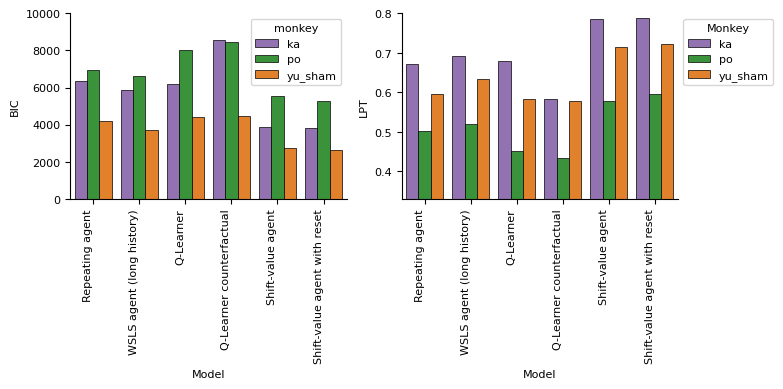

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set font size and figure size
plt.rcParams.update({'font.size': 8})
w, h = 20, 10

# Define the modes and figure
modes = ['BIC_CV', 'LPT_CV']
fig, axes = plt.subplots(1, 2, figsize=(w / 2.54, h / 2.54))

# Iterate over the modes and plot
for i, mode in enumerate(modes):
    ax = axes[i]
    
    # Create a bar plot directly from the DataFrame
    sns.barplot(
        data=res_all.loc[res_all['monkey'] != 'yu_DCZ'],
        x='Model',
        y=mode,
        hue='monkey',
        palette=COLORS,
        ax=ax,
        edgecolor='black',
        linewidth=0.5,
        legend=True,
    )
    
    # Configure axes
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Set y-axis limits and labels based on the mode
    if mode == 'BIC_CV':
        ax.set_ylim(0, 10000)
        ax.set_ylabel('BIC', fontsize=8)
    elif mode == 'LPT_CV':
        ax.set_ylim(0.33, 0.80)
        ax.set_yticks(np.arange(0.4, 0.9, 0.1))
        ax.set_ylabel('LPT', fontsize=8)
        ax.legend(title='Monkey', fontsize=8, loc='upper left', bbox_to_anchor=(1, 1), frameon=True)

# Adjust layout and save as SVG if needed
plt.tight_layout()
# Uncomment the following line to save the figure
plt.savefig('figs/lpt.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()